<a href="https://colab.research.google.com/github/Bachega/quantifier-recommender/blob/main/quantifier_recommender.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# init

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!pip install pymfe

import os
import numpy as np
import pandas as pd
# import arff
from scipy.io.arff import loadarff
import warnings
from pymfe.mfe import MFE
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn import svm
import sklearn.metrics as skm

path_arff = "drive/My Drive/Mestrado/data/datasets/arff/"
path_index = "drive/My Drive/Mestrado/data/index/arff/"
files_arff = os.listdir(path_arff)

path = "drive/My Drive/Mestrado/data/experimento/datasets/selected/cleaned/"
tablePath = savePath = "drive/My Drive/Mestrado/data/recommender/meta-features.csv"

ccTable = "drive/My Drive/Mestrado/data/recommender/meta-table-cc.csv"
dysTable = "drive/My Drive/Mestrado/data/recommender/meta-table-dys.csv"
accTable = "drive/My Drive/Mestrado/data/recommender/meta-table-acc.csv"
msTable = "drive/My Drive/Mestrado/data/recommender/meta-table-ms.csv"

algList = ['CC', 'DyS', 'ACC', 'MS']
pathList = [ccTable, dysTable, accTable, msTable]

files = os.listdir(path)

Mounted at /content/drive
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 16.2 MB/s eta 0:00:00


# utils

In [ ]:
class Distances(object):
    
    def __init__(self,P,Q):
        if sum(P)<1e-20 or sum(Q)<1e-20:
            raise "One or both vector are zero (empty)..."
        if len(P)!=len(Q):
            raise "Arrays need to be of equal sizes..."
        #use numpy arrays for efficient coding
        P=np.array(P,dtype=float);Q=np.array(Q,dtype=float)
        #Correct for zero values
        P[np.where(P<1e-20)]=1e-20
        Q[np.where(Q<1e-20)]=1e-20
        self.P=P
        self.Q=Q
        
    def sqEuclidean(self):
        P=self.P; Q=self.Q; d=len(P)
        return sum((P-Q)**2)
    
    def probsymm(self):
        P=self.P; Q=self.Q; d=len(P)
        return 2*sum((P-Q)**2/(P+Q))
    
    def topsoe(self):
        P=self.P; Q=self.Q
        return sum(P*np.log(2*P/(P+Q))+Q*np.log(2*Q/(P+Q)))
    def hellinger(self):
        P=self.P; Q=self.Q
        return 2 * np.sqrt(1 - sum(np.sqrt(P * Q)))


def DyS_distance(sc_1, sc_2, measure):
    
    dist = Distances(sc_1, sc_2)
    
    if measure == 'topsoe':
        return dist.topsoe()
    if measure == 'probsymm':
        return dist.probsymm()
    if measure == 'hellinger':
        return dist.hellinger()
    return 100


def TernarySearch(left, right, f, eps=1e-4):

    while True:
        if abs(left - right) < eps:
            return(left + right) / 2
    
        leftThird  = left + (right - left) / 3
        rightThird = right - (right - left) / 3
    
        if f(leftThird) > f(rightThird):
            left = leftThird
        else:
            right = rightThird 


def getHist(scores, nbins):
    breaks = np.linspace(0, 1, int(nbins)+1)
    breaks = np.delete(breaks, -1)
    breaks = np.append(breaks,1.1)
    
    re = np.repeat(1/(len(breaks)-1), (len(breaks)-1))  
    for i in range(1,len(breaks)):
        re[i-1] = (re[i-1] + len(np.where((scores >= breaks[i-1]) & (scores < breaks[i]))[0]) ) / (len(scores)+1)
    return re


"""This function implements MoSS. MoSS produces synthetic scores simulating distinct overlap scenarios of score distributions.
 
Parameters
----------
n : integer
    The number of scores for each label (posirive and negative).
alpha : float
    A float value ranged between [0-1], representing the positive label distribution.
m : float
    A float value representing the merging factor. When m=0, all positive observations have a score of one, while all negative 
    observations have a score of zero, turning classification perfect and, as a consequence, quantification a trivial task.
    On the other hand, when m=1, all scores for both classes are uniformly distributed within the interval [0,1], 
    turning it impossible to distinguish between classes.
Returns
-------
DataFrame
    A DataFrame containing the artificial scores for positive and negative labels. 
 """

def MoSS(n, alpha, m):
    p_scores = np.random.uniform(0,1,int(n*alpha))**m
    n_scores = 1-np.random.uniform(0,1,int(n*(1- alpha)))**m    
    scores  = pd.concat([pd.DataFrame(np.append(p_scores, n_scores)), pd.DataFrame(np.append(['1']*len(p_scores), ['2']*len(n_scores)))], axis=1)
    scores.columns = ['score', 'label']
    return p_scores, n_scores, scores

def DyS(pos_scores, neg_scores, test_scores, measure='topose'):
    
    bin_size = np.linspace(2,20,10)  #[10,20] range(10,111,10) #creating bins from 2 to 10 with step size 2
    bin_size = np.append(bin_size, 30)
    
    result  = []
    for bins in bin_size:
        #....Creating Histograms bins score\counts for validation and test set...............
        
        p_bin_count = getHist(pos_scores, bins)
        n_bin_count = getHist(neg_scores, bins)
        te_bin_count = getHist(test_scores, bins)
        
        def f(x):            
            return(DyS_distance(((p_bin_count*x) + (n_bin_count*(1-x))), te_bin_count, measure = measure))
    
        result.append(TernarySearch(0, 1, f))                                           
                        
    pos_prop = round(np.median(result),2)
    return pos_prop


def CC(test_scores,thr=0.5):
    
    count = len([i for i in test_scores if i >= thr])
    
    pos_prop = round(count/len(test_scores),2)
    num_predict = count
    
    return pos_prop


def getScores(dt, label, folds):
    
    skf = StratifiedKFold(n_splits=folds)    
    clf = RandomForestClassifier(n_estimators=200) # put here the classifier algorithm that will be used as scorer
    results = []
    class_labl = []
    
    for fold_i, (train_index,valid_index) in enumerate(skf.split(dt,label)):

        tr_data = pd.DataFrame(dt.iloc[train_index])   #Train data and labels
        tr_lbl = label.iloc[train_index]
        
        valid_data = pd.DataFrame(dt.iloc[valid_index])  #Validation data and labels
        valid_lbl = label.iloc[valid_index]
        
        clf.fit(tr_data, tr_lbl)
        
        results.extend(clf.predict_proba(valid_data)[:,1])     #evaluating scores
        class_labl.extend(valid_lbl)
    
    scr = pd.DataFrame(results,columns=["score"])
    scr_labl = pd.DataFrame(class_labl, columns= ["class"])
    scores = pd.concat([scr,scr_labl], axis = 1, ignore_index= False)
    
    return scores 


# preprocess

In [ ]:
tableList = []
for path in pathList:
  table = pd.read_csv(path)
  table.drop(82, inplace = True)
  data = table.values
  X, y = data[:, :-1], data[:, -1]
  np.nan_to_num(X, copy = False)
  tableList.append((X, y))

# meta_table_cc = pd.read_csv(ccTable)
# meta_table_dys = pd.read_csv(dysTable)
# meta_table_acc = pd.read_csv(accTable)
# meta_table_ms = pd.read_csv(accTable)

# meta_table_cc.drop(82, inplace = True)
# meta_table_dys.drop(82, inplace = True)
# meta_table_acc.drop(82, inplace = True)
# meta_table_ms.drop(82, inplace = True)

# data = meta_table_cc.values
# X_cc, y_cc = data[:, :-1], data[:, -1]
# np.nan_to_num(X_cc, copy = False)

# data = meta_table_dys.values
# X_dys, y_dys = data[:, :-1], data[:, -1]
# np.nan_to_num(X_dys, copy = False)

# data = meta_table_acc.values
# X_acc, y_acc = data[:, :-1], data[:, -1]
# np.nan_to_num(X_dys, copy = False)

# data = meta_table_ms.values
# X_ms, y_ms = data[:, :-1], data[:, -1]
# np.nan_to_num(X_dys, copy = False)

# print('Done')

# experiment

In [ ]:
data = []
model = RandomForestRegressor(random_state=42)

instance_len = len(tableList[0][0])
results = {}
j = 0
for (X, y) in tableList:
  resultsList = []
  algName = algList[j]
  j += 1
  
  for i in range(0, len(X)):
    X_train = np.delete(X, i, 0)
    y_train = np.delete(y, i, 0)

    X_test = X[i]
    X_test = X_test.reshape(1, -1)
    y_test = y[i]

    model.fit(X_train, y_train)
    abs_error = model.predict(X_test)

    resultsList.append([y_test, abs_error[0]])

  results[algName] = resultsList

cols = []
for key in results:
  cols.append('abs-error-'+key)
  cols.append('abs-error-'+key+'-predicted')
cols.append('abs-error-ideal')
cols.append('quantifier-ideal')
cols.append('quantifier-ideal-num')
cols.append('abs-error-recommended')
cols.append('quantifier-recommended')
cols.append('quantifier-recommended-num')


for i in range(0, instance_len):
  abs_error_ideal = 2
  quantifier_ideal = 'NULL'
  quantifier_ideal_num = -1
  abs_error_recommended = 2
  quantifier_recommended = 'NULL'
  quantifier_recommended_num = -1
  row = []
  algNum = 0

  for a in algList:
    row.append(results[a][i][0])
    row.append(results[a][i][1])

    # print(results[a][i][0])

    if results[a][i][0] < abs_error_ideal:
      abs_error_ideal = results[a][i][0]
      quantifier_ideal = a
      quantifier_ideal_num = algNum
    
    if results[a][i][1] < abs_error_recommended:
      abs_error_recommended = results[a][i][1]
      quantifier_recommended = a
      quantifier_recommended_num = algNum

    algNum += 1

  row.append(abs_error_ideal)
  row.append(quantifier_ideal)
  row.append(quantifier_ideal_num)
  row.append(abs_error_recommended)
  row.append(quantifier_recommended)
  row.append(quantifier_recommended_num)

  data.append(row)

table = pd.DataFrame(data, columns = cols)
table


# columns = ['abs-error-cc', # 1
#            'abs-error-cc-predicted', # 2
#            'abs-error-dys', # 3
#            'abs-error-dys-predicted', # 4
#            'abs-error-ideal', # 5
#            'quantifier-ideal', # 6
#            'quantifier-ideal-num', #7
#            'abs-error-recommended', # 8
#            'quantifier-recommended', # 9
#            'quantifier-recommended-num'] # 10

# for i in range(0, instance_len):
#   for

#   data.append([y_test_cc, # 1
#                cc_abs_error[0], # 2
#                y_test_dys, # 3
#                dys_abs_error[0], # 4
#                y_test_cc if y_test_cc < y_test_dys else y_test_dys, # 5
#                'CC' if y_test_cc < y_test_dys else 'DyS', # 6
#                0 if y_test_cc < y_test_dys else 1, # 7
#                abs_error_rec, # 8
#                'CC' if cc_abs_error[0] < dys_abs_error[0] else 'DyS', # 9
#                 0 if cc_abs_error[0] < dys_abs_error[0] else 1]) # 10

,abs-error-CC,abs-error-CC-predicted,abs-error-DyS,abs-error-DyS-predicted,abs-error-ACC,abs-error-ACC-predicted,abs-error-MS,abs-error-MS-predicted,abs-error-ideal,quantifier-ideal,quantifier-ideal-num,abs-error-recommended,quantifier-recommended,quantifier-recommended-num
0,0.00805,0.034895,0.00510,0.040380,0.00805,0.040662,0.00510,0.035002,0.00510,DyS,1,0.034895,CC,0
1,0.03105,0.072187,0.01095,0.032653,0.01540,0.044024,0.01330,0.043297,0.01095,DyS,1,0.032653,DyS,1
2,0.03410,0.065632,0.01535,0.028534,0.02210,0.030444,0.01765,0.030334,0.01535,DyS,1,0.028534,DyS,1
3,0.06440,0.075624,0.01660,0.061141,0.02100,0.068081,0.01835,0.064624,0.01660,DyS,1,0.061141,DyS,1
4,0.05315,0.332944,0.01075,0.055725,0.01895,0.087271,0.01420,0.078445,0.01075,DyS,1,0.055725,DyS,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,0.15380,0.166403,0.20140,0.187713,0.11970,0.208700,0.15270,0.211206,0.11970,ACC,2,0.166403,CC,0
129,0.18855,0.151807,0.03605,0.043021,0.05220,0.076462,0.03935,0.044831,0.03605,DyS,1,0.043021,DyS,1
130,0.11130,0.178739,0.04815,0.176280,0.16295,0.211615,0.11035,0.205790,0.04815,DyS,1,0.176280,DyS,1
131,0.16725,0.156461,0.06955,0.069593,0.09575,0.099187,0.08325,0.097899,0.06955,DyS,1,0.069593,DyS,1


In [ ]:
table['quantifier-recommended-num'].value_counts()

1    91
3    20
0    16
2     6
Name: quantifier-recommended-num, dtype: int64

In [ ]:
ideal = table['quantifier-ideal-num'].values
pred = table['quantifier-recommended-num'].values

acc = (pred == ideal)
# acc

acc = np.count_nonzero(acc) / len(acc)
print('Accuracy: ' + str(acc))

Accuracy: 0.48872180451127817


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

paux = table['quantifier-recommended-num'].T
taux = table['quantifier-ideal-num'].T
paux = paux.values
taux = taux.values

predicted = []
true = []

for i in range(0, len(paux)):
  predicted.append(int(paux[i]))
  true.append(int(taux[i]))

cm = confusion_matrix(true, predicted)
cm

array([[ 5, 10,  1,  3],
       [ 3, 58,  3, 14],
       [ 4,  4,  0,  1],
       [ 4, 19,  2,  2]])

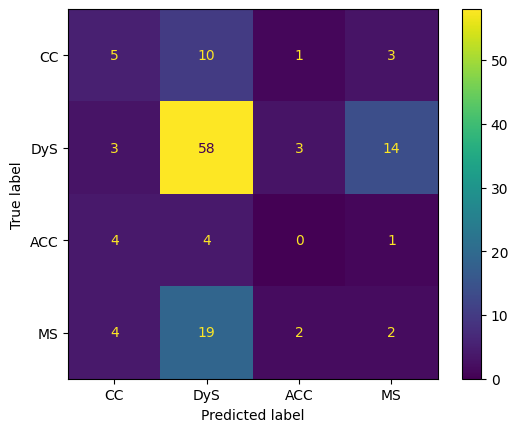

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=algList)

disp.plot()

plt.show()